# Superstore Sales & Profit Analysis

An exploratory data analysis project aimed at identifying key sales drivers, profitability trends, discount effectiveness, and business opportunities using the Superstore dataset.

## Business Objective

This project aims to analyze Superstore's historical sales data to:

- Identify top-performing regions and categories
- Investigate profitability trends
- Evaluate the impact of discounts
- Discover seasonal sales patterns
- Provide actionable business recommendations

## Setup

In [41]:
#Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [42]:
#Load Dataset
df = pd.read_csv(r"D:\Sample_Superstore.csv", encoding="latin1")


## Data Understanding

In [43]:
#Quick overview of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [44]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [45]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [46]:
#Checking categorical values
df["Segment"].unique()



array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [47]:
df['Region'].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [48]:
df['State'].unique()

array(['Kentucky', 'California', 'Florida', 'North Carolina',
       'Washington', 'Texas', 'Wisconsin', 'Utah', 'Nebraska',
       'Pennsylvania', 'Illinois', 'Minnesota', 'Michigan', 'Delaware',
       'Indiana', 'New York', 'Arizona', 'Virginia', 'Tennessee',
       'Alabama', 'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio',
       'Missouri', 'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut',
       'New Jersey', 'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Montana', 'New Hampshire', 'Maryland',
       'District of Columbia', 'Kansas', 'Vermont', 'Maine',
       'South Dakota', 'Idaho', 'North Dakota', 'Wyoming',
       'West Virginia'], dtype=object)

In [49]:
df['Category'].value_counts().sort_values(ascending=False)

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

## Data Cleaning

In [50]:
# checking missing values
df.isnull().sum() 



Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [51]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

In [52]:
# Converting to date time

df['Order Date']= pd.to_datetime(df['Order Date']) 
df['Ship Date']= pd.to_datetime(df['Ship Date']) 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [53]:
#Converting time data to month and year
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## EDA 


<Axes: xlabel='Sales', ylabel='Count'>

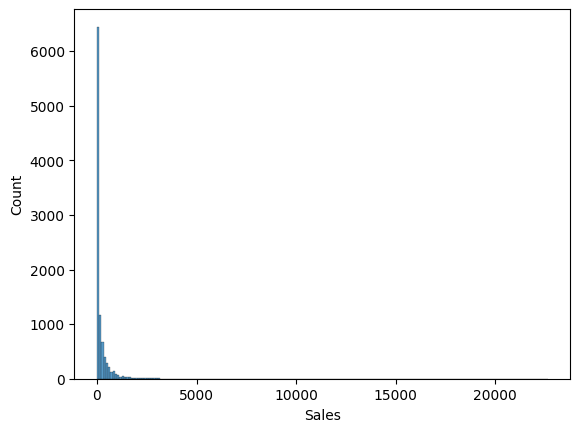

In [54]:
sns.histplot(df['Sales'])

<Axes: xlabel='Profit', ylabel='Count'>

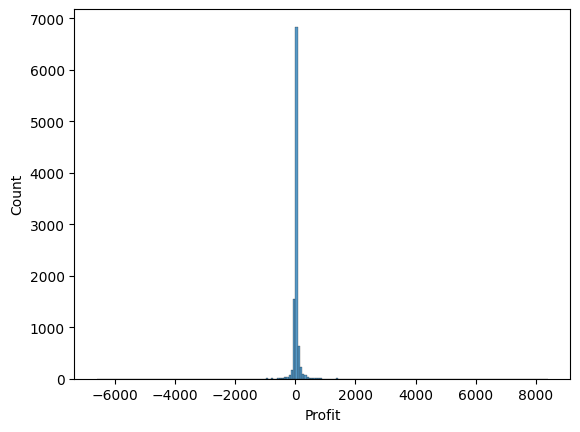

In [55]:
sns.histplot(df['Profit'])

1167


<Axes: xlabel='Sales'>

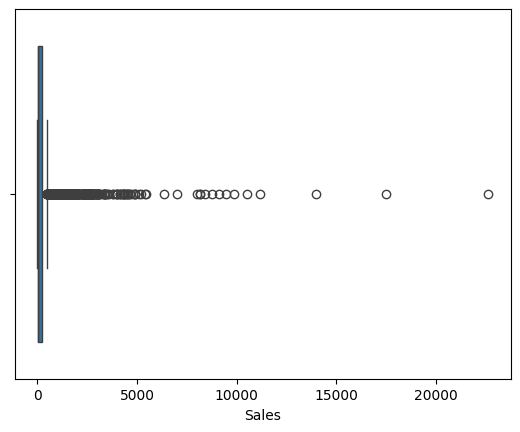

In [56]:
#Checking Sales  Outliers 
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print(len(outliers))

sns.boxplot(x=df['Sales'])


1881


<Axes: xlabel='Profit'>

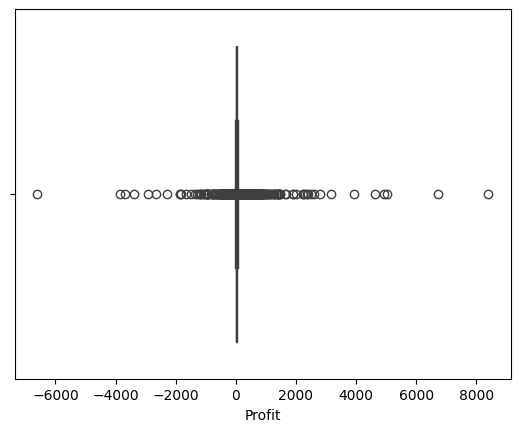

In [57]:
# Checking Profit Outliers
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75) 
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]
print(len(outliers))

sns.boxplot(x=df['Profit'])

<Axes: >

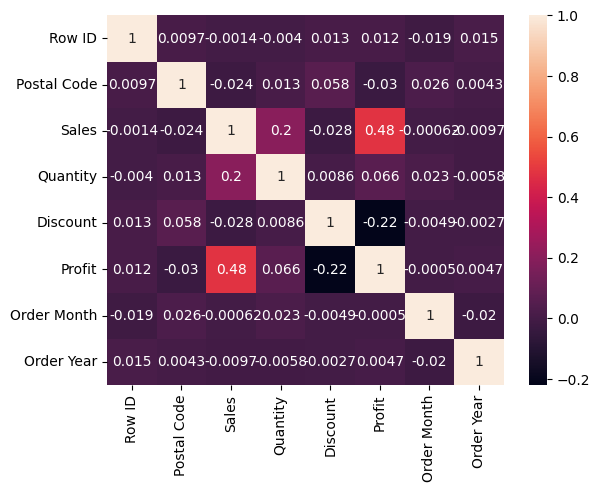

In [58]:
# To check the correlation between the numerical variables
sns.heatmap(df.corr(numeric_only=True), annot=True)


## Regional Analysis
To find which region had the most Sales and Profit

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


Text(0.5, 1.0, 'Total Profit by Region')

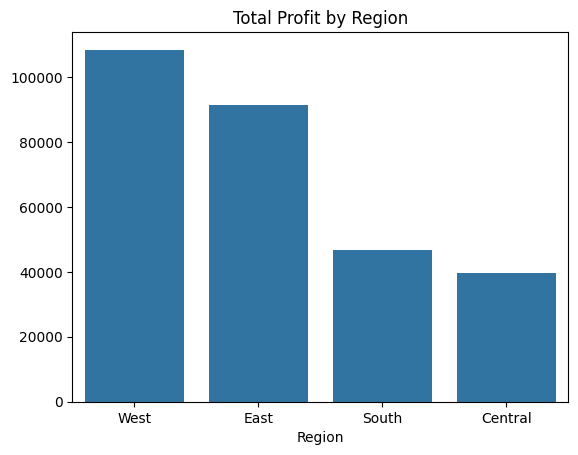

In [59]:
#regions performance by profit
top_regions = df.groupby('Region')['Profit'].sum().sort_values( ascending=False)
print(top_regions)
sns.barplot(x=top_regions.index, y=top_regions.values)
plt.title('Total Profit by Region')

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


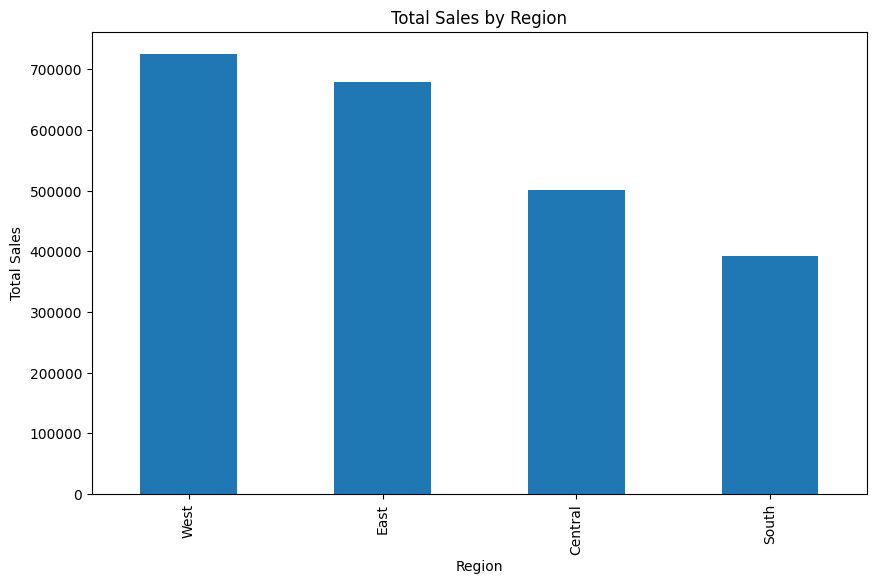

In [60]:
grp_by_region= df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(grp_by_region) 

grp_by_region.plot(kind='bar', figsize=(10,6))
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Name: Profit, dtype: float64


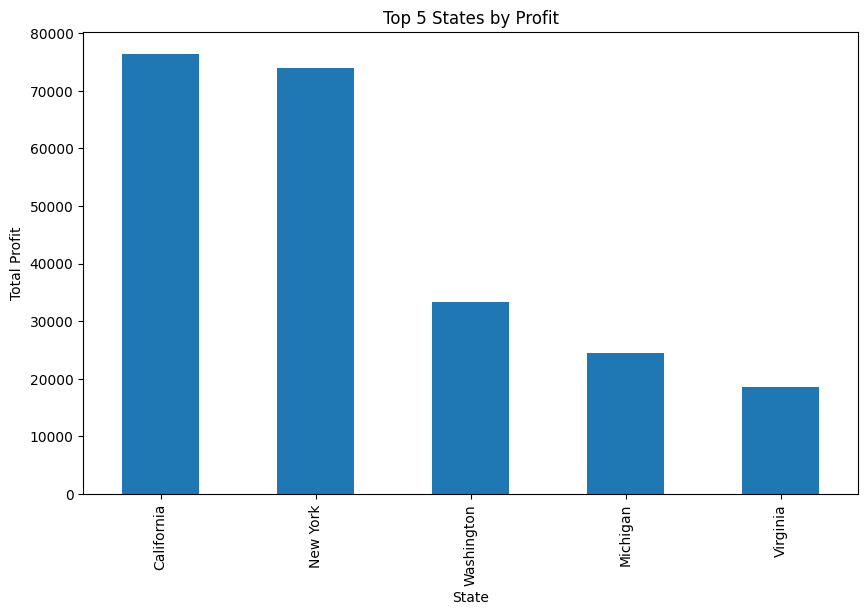

In [61]:
# Top 5 states with the highest sales and profit 
top5_state=df.groupby('State')['Profit'].sum().sort_values( ascending=False).head(5)
print(top5_state)

top5_state.plot(kind='bar', figsize=(10,6))
plt.title('Top 5 States by Profit')
plt.xlabel('State')
plt.ylabel('Total Profit')
plt.show()

                      Sales      Profit
City                                   
Los Angeles      175851.341  30440.7579
Seattle          119540.742  29156.0967
San Francisco    112669.092  17507.3854
San Diego         47521.029   6377.1960
Denver            12198.793   -244.9200
...                     ...         ...
Billings              8.288      2.6936
Layton                4.960      2.3312
Auburn                4.180      1.5048
Everett               3.856      1.3978
San Luis Obispo       3.620      1.1946

[169 rows x 2 columns]


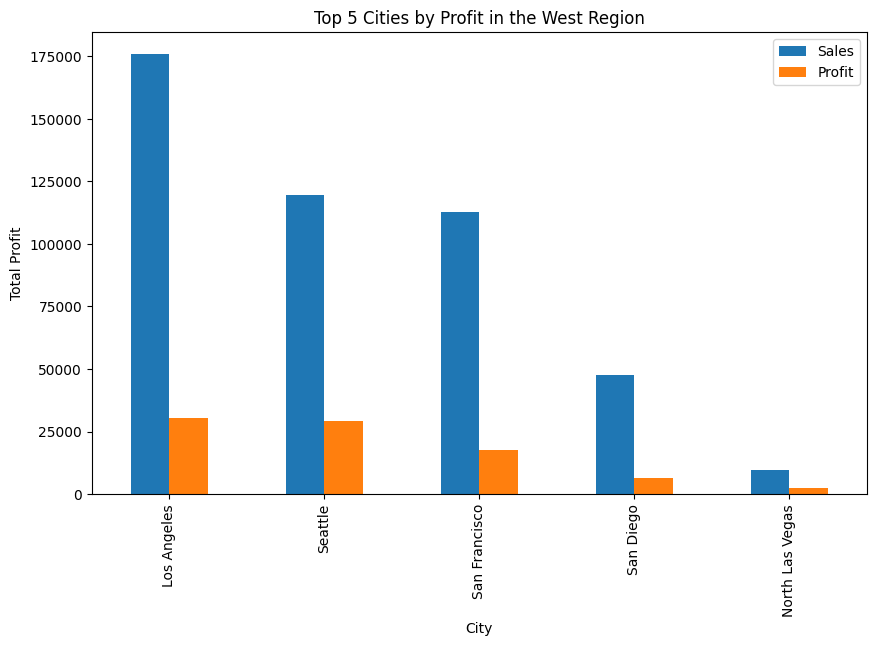

In [62]:
# Which city in the west region has the highest sales and profit? 

west_region = df[df['Region'] == 'West']
city_sales_profit = west_region.groupby('City')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False) 
print(city_sales_profit)

city_sales_profit.nlargest(5, 'Profit').plot(kind='bar', figsize=(10,6))
plt.title('Top 5 Cities by Profit in the West Region')
plt.xlabel('City')
plt.ylabel('Total Profit')
plt.show()

## Category analysis

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


Text(0.5, 1.0, 'Total Profit by Category')

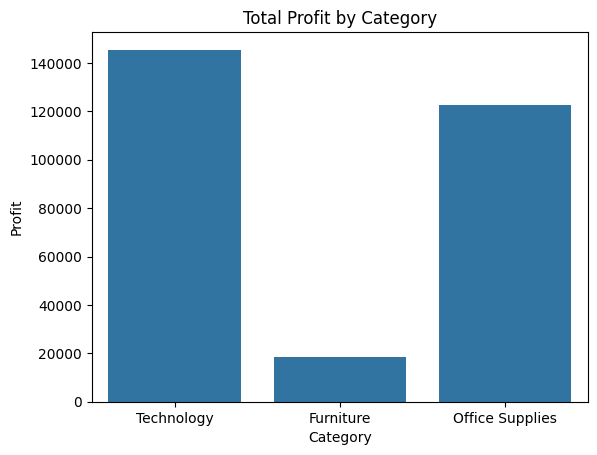

In [63]:
# Top categories by sales and profit 
top_categories = df.groupby('Category')[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False)
print(top_categories)

sns.barplot(x=top_categories.index, y=top_categories['Profit'])
plt.title('Total Profit by Category')

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Name: Profit, dtype: float64


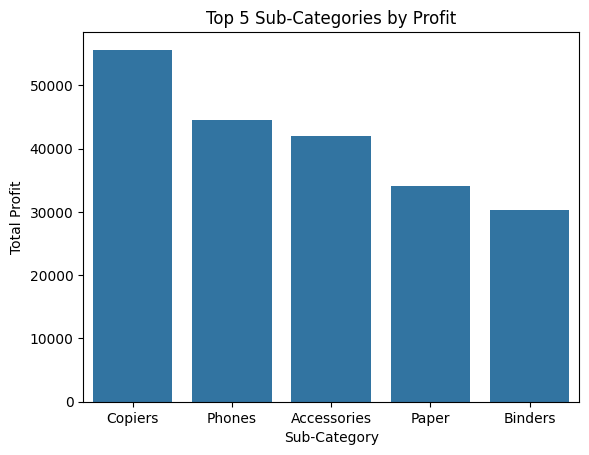

In [64]:
#Which sub-category has the highest profit in the entire dataset?
sub_category_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(5)
print(sub_category_profit)
sns.barplot(x=sub_category_profit.index, y=sub_category_profit.values)
plt.title('Top 5 Sub-Categories by Profit')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.show()

Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64


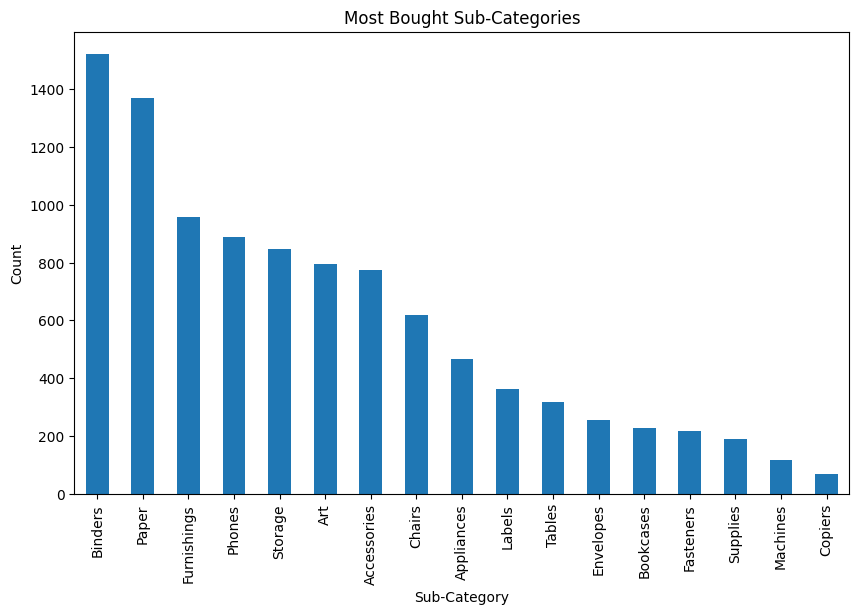

In [65]:
#Most bought sub-category
most_bought= df['Sub-Category'].value_counts().sort_values(ascending=False)
print(most_bought)
most_bought.plot(kind='bar', figsize=(10,6))
plt.title('Most Bought Sub-Categories')
plt.xlabel('Sub-Category')
plt.ylabel('Count')
plt.show()

Sub-Category
Copiers        19327.2351
Accessories    16484.5983
Binders        16096.8016
Paper          12119.2364
Phones          9110.7426
Storage         8645.3222
Appliances      8261.2699
Furnishings     7641.2704
Chairs          4027.5843
Art             2374.0970
Labels          2303.1223
Envelopes       1908.7624
Tables          1482.6073
Supplies         626.0465
Fasteners        275.1907
Machines        -618.9264
Bookcases      -1646.5117
Name: Profit, dtype: float64


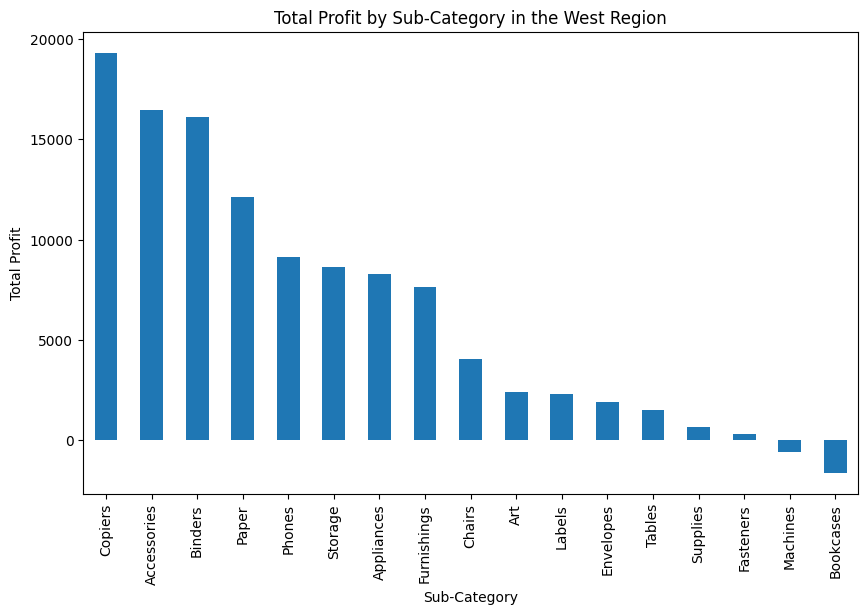

In [66]:
#Highest sales and profit by sub-category in the west region
west_region = df[df['Region'] == 'West']
best_category_west = west_region.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print(best_category_west)
best_category_west.plot(kind='bar', figsize=(10,6))
plt.title('Total Profit by Sub-Category in the West Region')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.show()


## Segment Analysis

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


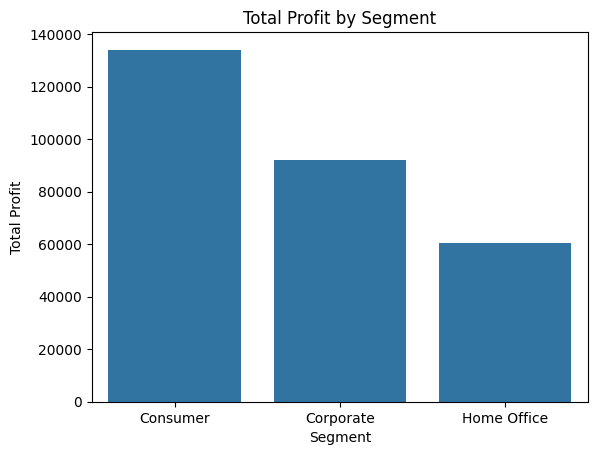

In [67]:
# profit by segment
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
print(segment_profit)
sns.barplot(x=segment_profit.index, y=segment_profit.values)
plt.title('Total Profit by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Profit')
plt.show()

       Segment         Category      Profit
2     Consumer       Technology  70797.8096
1     Consumer  Office Supplies  56330.3210
5    Corporate       Technology  44166.9980
4    Corporate  Office Supplies  40227.3202
8  Home Office       Technology  30490.1405
7  Home Office  Office Supplies  25933.1596
3    Corporate        Furniture   7584.8158
0     Consumer        Furniture   6991.0786
6  Home Office        Furniture   3875.3784


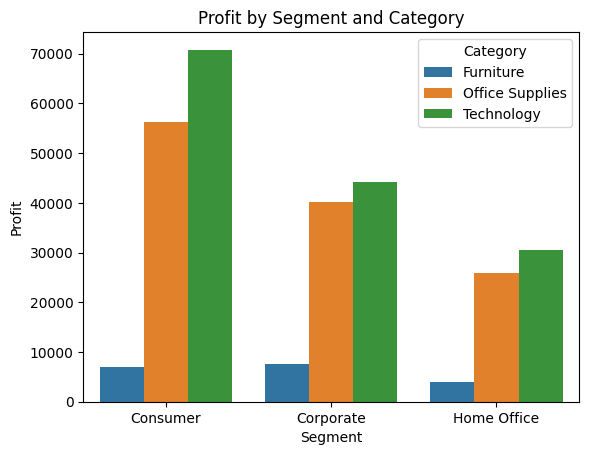

In [68]:
segment_category_profit = df.groupby(['Segment','Category'])['Profit'].sum().reset_index()
print(segment_category_profit.sort_values(by='Profit', ascending=False))
sns.barplot(data=segment_category_profit, x='Segment', y='Profit', hue='Category')
plt.title('Profit by Segment and Category')
plt.show()

## Time Analysis

Order Year        2014        2015        2016        2017
Region                                                    
Central       539.5534  11716.8020  19899.1629   7550.8442
East        17059.6095  21091.0130  20141.5961  33230.5614
South       11879.1200   8318.5940  17702.8084   8848.9079
West        20065.6912  20492.1947  24051.6069  43808.9561


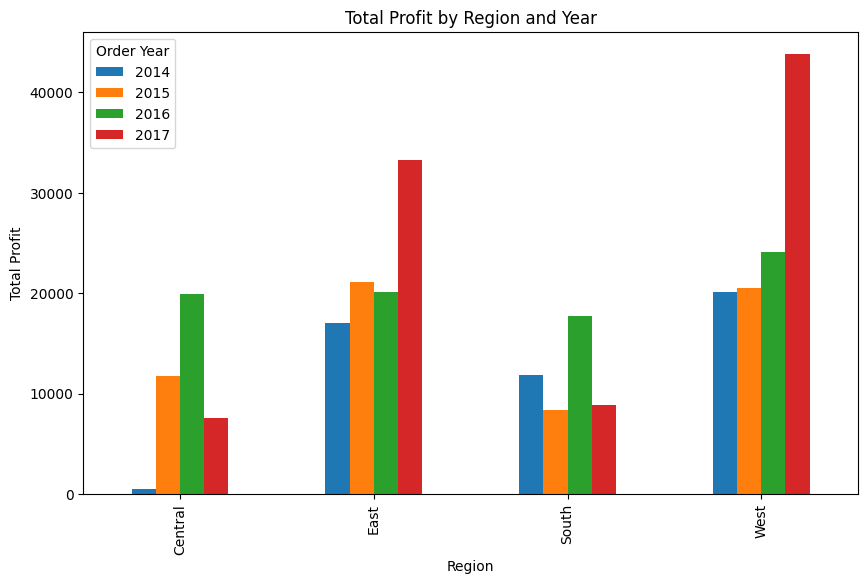

In [69]:
# Total profit by region and year
profit_by_region_year = df.pivot_table(values='Profit', index='Region', columns='Order Year', aggfunc='sum')
print(profit_by_region_year)

profit_by_region_year.plot(kind='bar', figsize=(10,6))
plt.title('Total Profit by Region and Year')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()

Order Month
11    352461.0710
12    325293.5035
9     307649.9457
3     205005.4888
10    200322.9847
8     159044.0630
5     155028.8117
6     152718.6793
7     147238.0970
4     137762.1286
1      94924.8356
2      59751.2514
Name: Sales, dtype: float64


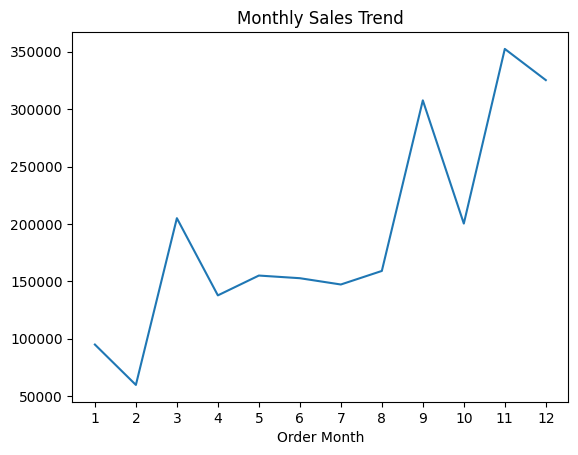

In [70]:
#sales monthly trend 
monthly_sales_trend = df.groupby('Order Month')['Sales'].sum()
print(monthly_sales_trend.sort_values(ascending=False))
sns.lineplot(x=monthly_sales_trend.index, y=monthly_sales_trend.values)
plt.title('Monthly Sales Trend')
plt.xticks(monthly_sales_trend.index)
plt.show()

Order Year
2017    733215.2552
2016    609205.5980
2014    484247.4981
2015    470532.5090
Name: Sales, dtype: float64


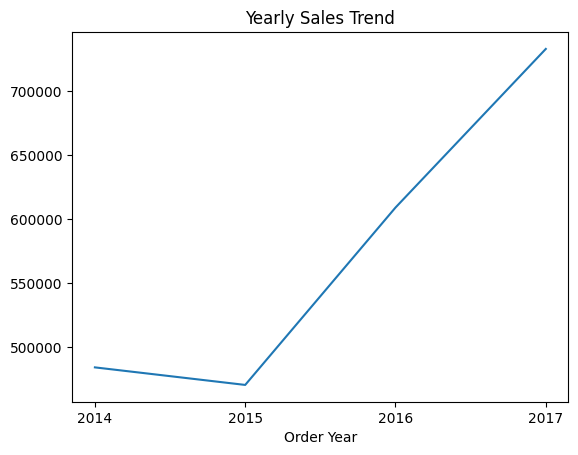

In [71]:
#Yearly sales trend
yearly_sales_trend = df.groupby('Order Year')['Sales'].sum()
print(yearly_sales_trend.sort_values(ascending=False))
sns.lineplot(x=yearly_sales_trend.index, y=yearly_sales_trend.values)
plt.title('Yearly Sales Trend')
plt.xticks(yearly_sales_trend.index) 

plt.show()

Order Year
2017    93439.2696
2016    81795.1743
2015    61618.6037
2014    49543.9741
Name: Profit, dtype: float64


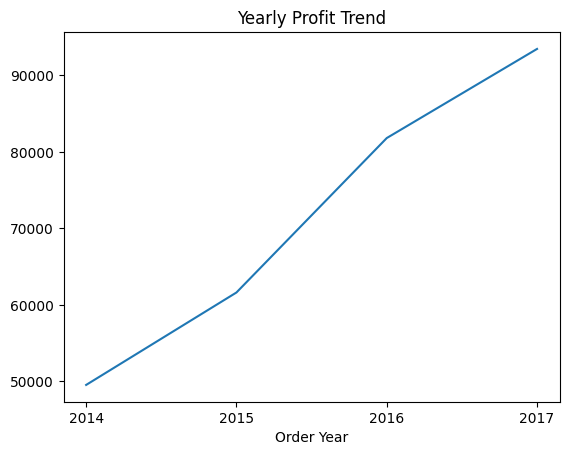

In [72]:
yearly_profit = df.groupby('Order Year')['Profit'].sum().sort_values(ascending=False)
print(yearly_profit)
sns.lineplot(x=yearly_profit.index, y=yearly_profit.values)
plt.title('Yearly Profit Trend')
plt.xticks(yearly_profit.index)
plt.show()

Order Month
12    43369.1919
9     36857.4753
11    35468.4265
10    31784.0413
3     28594.6872
5     22411.3078
8     21776.9384
6     21285.7954
7     13832.6648
4     11587.4363
2     10294.6107
1      9134.4461
Name: Profit, dtype: float64


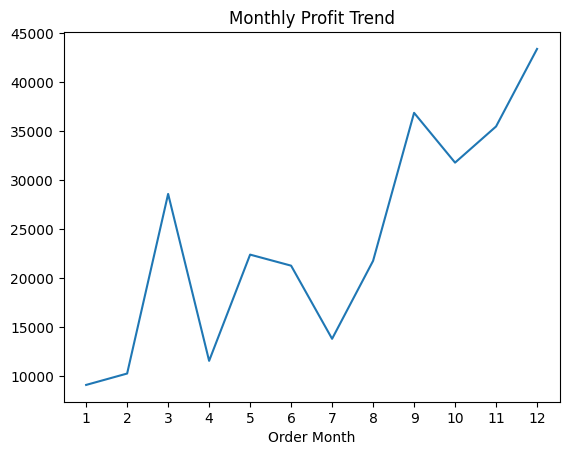

In [73]:
monthly_profit = df.groupby('Order Month')['Profit'].sum().sort_values(ascending=False)
print(monthly_profit)
sns.lineplot(x=monthly_profit.index, y=monthly_profit.values)
plt.title('Monthly Profit Trend')  
plt.xticks(monthly_profit.index)
plt.show()

## Disount Analysis

In [74]:
#products with highest discounts 
highest_discounts = df.nlargest(5, 'Discount')
print(highest_discounts[['Sub-Category', 'Discount']])

    Sub-Category  Discount
14    Appliances       0.8
15       Binders       0.8
75       Binders       0.8
101      Binders       0.8
169   Appliances       0.8


In [75]:
# average discount by category
average_discounts = df.groupby('Category')['Discount'].mean().sort_values(ascending=False)
print(average_discounts)

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64


In [76]:
# average discount by sub-category
average_discounts = df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False)
print(average_discounts)

Sub-Category
Binders        0.372292
Machines       0.306087
Tables         0.261285
Bookcases      0.211140
Chairs         0.170178
Appliances     0.166524
Copiers        0.161765
Phones         0.154556
Furnishings    0.138349
Fasteners      0.082028
Envelopes      0.080315
Accessories    0.078452
Supplies       0.076842
Paper          0.074891
Art            0.074874
Storage        0.074704
Labels         0.068681
Name: Discount, dtype: float64


In [77]:
df.groupby('Discount').agg({
    'Order ID':'nunique',
    'Sales':'median',
    'Profit':'mean',
    'Quantity':'sum'
}).sort_values(by='Profit', ascending=False)

,Order ID,Sales,Profit,Quantity
Discount,,,,
0.10,89,327.7800,96.055074,373
0.00,2644,53.5500,66.900292,18267
0.15,51,359.4990,27.288298,198
0.20,2407,51.9840,24.702572,13660
0.60,127,22.4940,-43.077212,501
0.30,211,359.0580,-45.679636,849
0.32,27,328.3992,-88.560656,105
0.70,344,12.2940,-95.874060,1660
0.80,250,8.7010,-101.796797,1188


## Shipping Analysis

In [78]:
#Which category and ship mode combination has the highest profit?
Category_shipment = df.groupby(['Category','Ship Mode'])['Profit'].sum().sort_values(ascending=False)
print(Category_shipment) 

Category         Ship Mode     
Technology       Standard Class    83129.2870
Office Supplies  Standard Class    70598.7849
Technology       First Class       27502.5634
Office Supplies  Second Class      27068.1676
Technology       Second Class      26152.2064
Office Supplies  First Class       18400.3291
Furniture        Standard Class    10360.7156
Technology       Same Day           8670.8913
Office Supplies  Same Day           6423.5192
Furniture        Second Class       4226.2614
                 First Class        3066.9474
                 Same Day            797.3484
Name: Profit, dtype: float64


## Insights 

- The west region had the highest sales and profit among all regions,making it the strongest-performing market for Superstore.

- Orders with Discount less than 30 % generated the positive profits compared with big discounts that generated negative profits.

- December was the most profitable month, while 2017 recorded the highest annual profit, exceeding $44,000. 

- The technology category is the strongest category profitability wise, making it play an important role in the store overall performance.

- Technology products shipped through Standard Class generated the highest sales revenue among all category and shipping mode combinations.

- The Consumer segment generated the highest sales and profit among all customer segments. Within this segment, Technology products contributed the largest share of profit, highlighting the importance of Consumer customers to the company's overall financial performance. 

## Buisness Recommendation

- The superstore should optimize their discount policy and limit them to maximum 30 %, as higher disocunts lead to negative profit. 

- Superstore should continue investing in the West region and the Technology category through targeted marketing, inventory expansion, and customer retention initiatives, as these areas contribute the highest sales and profit.